In [1]:
#!pip install alpaca-py #newer base
#!pip install alpaca-trade-api
#!pip install mplfinance

In [2]:
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from datetime import datetime
import pandas as pd

In [3]:
# Alpaca API credentials
API_KEY = "PKP6G2PCSLR7KABZBU9Z"
API_SECRET = "mPNf9KoilrmoMdz4MedQdeaZWxda3D1YjgCIJbjd"

client = StockHistoricalDataClient(API_KEY, API_SECRET)

In [4]:
SUPPORTED_TIMEFRAMES = {
    "Minute": [1, 5, 15],
    "Hour": [1],
    "Day": [1]
}

#i belive i can call multiple tickers at the same time
# i can also call multiple timeframes at the same time

def get_stock_data(symbol: str, start_date: str, end_date: str,
                   timeframe_unit: str = "Day", multiplier: int = 1):
    if timeframe_unit not in SUPPORTED_TIMEFRAMES:
        raise ValueError(f"Unsupported timeframe unit: {timeframe_unit}")
    if multiplier not in SUPPORTED_TIMEFRAMES[timeframe_unit]:
        raise ValueError(f"Unsupported multiplier '{multiplier}' for '{timeframe_unit}'")

    unit_enum = TimeFrameUnit[timeframe_unit]
    alpaca_timeframe = TimeFrame(multiplier, unit_enum)

    request_params = StockBarsRequest(
        symbol_or_symbols=[symbol],
        timeframe=alpaca_timeframe,
        start=datetime.strptime(start_date, "%Y-%m-%d"),
        end=datetime.strptime(end_date, "%Y-%m-%d")
    )

    bars = client.get_stock_bars(request_params)
    df = bars.df

    # Handle both flat and MultiIndex column cases
    if isinstance(df.columns, pd.MultiIndex):
        if symbol in df.columns.levels[0]:
            df = df.xs(symbol, axis=1, level=0)
        else:
            raise KeyError(f"Symbol '{symbol}' not found in returned data columns.")
    
    # Check for required columns and raise helpful error if missing
    required_cols = ['open', 'high', 'low', 'close', 'volume']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in data: {missing}\nAvailable columns: {df.columns.tolist()}")

    # Clean non-trading days
    df = df.dropna(subset=['open', 'high', 'low', 'close', 'volume'])

    # Drop fake/no-trade rows
    df = df[~(
        (df['open'] == df['high']) &
        (df['high'] == df['low']) &
        (df['low'] == df['close']) &
        (df['volume'] == 0)
    )]

    return df[required_cols]



In [5]:
def plot_candlestick_with_volume(df, symbol: str):
    # If MultiIndex (e.g., (symbol, datetime)), reduce to datetime index
    if isinstance(df.index, pd.MultiIndex):
        df = df.reset_index(level=0, drop=True)

    # Ensure index is datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # Reset index for plotting
    df_plot = df.copy().reset_index()
    df_plot.rename(columns={df_plot.columns[0]: 'timestamp'}, inplace=True)

    # Use integer x positions (0, 1, 2, ...) to enforce uniform spacing
    df_plot['x'] = range(len(df_plot))

    # Build OHLC data
    quotes = list(zip(
        df_plot['x'],
        df_plot['open'],
        df_plot['high'],
        df_plot['low'],
        df_plot['close']
    ))

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})

    candlestick_ohlc(ax1, quotes, width=0.6, colorup='g', colordown='r', alpha=0.8)
    ax1.set_title(f'{symbol} Candlestick Chart')
    ax1.set_ylabel('Price')
    ax1.grid(True)

    # Volume bars
    ax2.bar(df_plot['x'], df_plot['volume'], color='gray', width=0.6)
    ax2.set_ylabel('Volume')
    ax2.grid(True)

    # Set x-ticks to timestamps
    tick_interval = max(1, len(df_plot) // 10)
    ax2.set_xticks(df_plot['x'][::tick_interval])
    ax2.set_xticklabels(df_plot['timestamp'].dt.strftime('%Y-%m-%d')[::tick_interval], rotation=45)

    plt.tight_layout()
    plt.show()


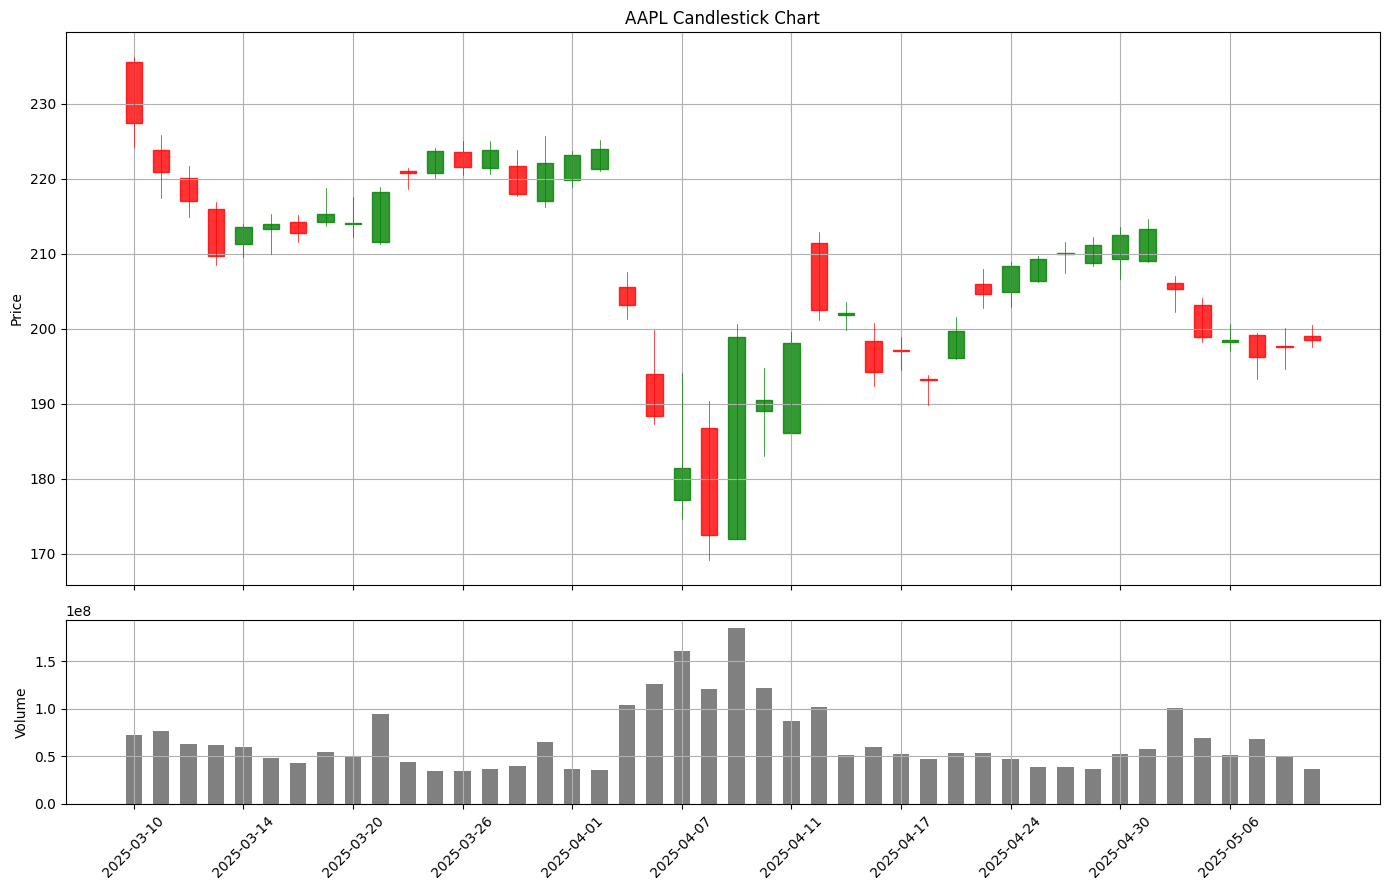

In [6]:
# Example usage
symbol = "AAPL"
start_date = "2025-03-10"
end_date = "2025-05-10"
timeframe_unit = "Day"  # or "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)
# Plot candlestick chart with volume
plot_candlestick_with_volume(df, symbol)

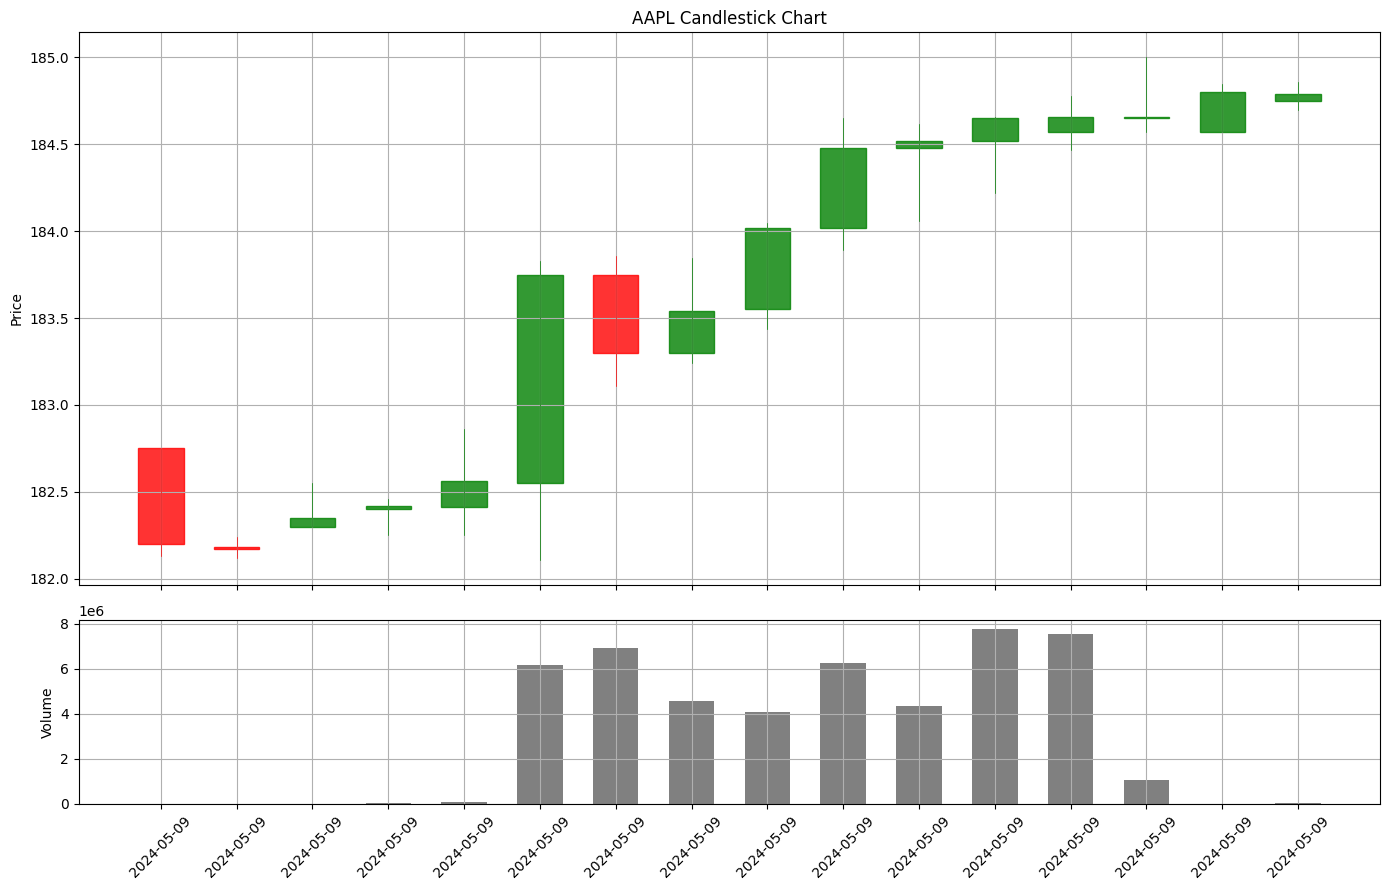

In [7]:
# Example usage
symbol = "AAPL"
start_date = "2024-05-9"
end_date = "2024-05-10"
timeframe_unit = "Hour"  # or "Minute", "Hour"
multiplier = 1
# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)
# Plot candlestick chart with volume
plot_candlestick_with_volume(df, symbol)

In [8]:
# import pandas as pd
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# def plot_candlestick_interactive(df: pd.DataFrame, symbol: str):
#     # Prepare DataFrame
#     if isinstance(df.index, pd.MultiIndex):
#         df = df.reset_index(level=0, drop=True)
#     df.index = pd.to_datetime(df.index)

#     # Create 2-row subplot: row1=candlestick, row2=bar
#     fig = make_subplots(
#         rows=2, cols=1,
#         shared_xaxes=True,
#         row_heights=[0.65, 0.35],     # top slightly shorter, bottom slightly taller
#         specs=[[{"type": "candlestick"}],
#                [{"type": "bar"}]],
#         vertical_spacing=0.08,        # more space between subplots
#         subplot_titles=(f"{symbol} Price", "Volume")
#     )

#     # --- Top: Candlestick ---
#     fig.add_trace(
#         go.Candlestick(
#             x=df.index,
#             open=df['open'],
#             high=df['high'],
#             low=df['low'],
#             close=df['close'],
#             showlegend=False
#         ),
#         row=1, col=1
#     )

#     # --- Bottom: Volume bars only ---
#     fig.add_trace(
#         go.Bar(
#             x=df.index,
#             y=df['volume'],
#             marker_color='gray',
#             showlegend=False
#         ),
#         row=2, col=1
#     )

#     # Build tick labels: HH:MM normally, full date when the day changes
#     dates    = df.index
#     tickvals = []
#     ticktext = []
#     prev_day = None
#     for dt in dates:
#         tickvals.append(dt)
#         if prev_day is None or dt.date() != prev_day:
#             ticktext.append(dt.strftime("%Y-%m-%d"))
#         else:
#             ticktext.append(dt.strftime("%H:%M"))
#         prev_day = dt.date()

#     # Apply to the shared x-axis (on row2)
#     fig.update_xaxes(
#         row=2, col=1,
#         tickmode="array",
#         tickvals=tickvals,
#         ticktext=ticktext,
#         ticks="outside",
#         tickangle=45
#     )

#     # Y-axis labels
#     fig.update_yaxes(title_text="Price", row=1, col=1)
#     fig.update_yaxes(title_text="Volume", row=2, col=1)

#     # Final layout
#     fig.update_layout(
#         height=600,
#         margin=dict(t=50, b=100),    # increased bottom margin
#         hovermode="x unified"
#     )

#     fig.show()

# # Example usage
# # symbol = "AAPL"
# # df = your_dataframe_here
# # plot_candlestick_interactive(df, symbol)


In [9]:
# # Example usage
# symbol = "AAPL"
# start_date = "2024-05-5"
# end_date = "2024-05-10"
# timeframe_unit = "Hour"  # or "Minute", "Hour"
# multiplier = 1

# # Get stock data
# df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)

# # Interactive:
# plot_candlestick_interactive(df, symbol)


In [10]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_candlestick_interactive(df: pd.DataFrame, symbol: str):
    # --- Prepare DataFrame & categorical x-axis strings ---
    if isinstance(df.index, pd.MultiIndex):
        df = df.reset_index(level=0, drop=True)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()  # ensure chronological

    # create a string version of each timestamp
    x_str = df.index.strftime("%Y-%m-%d %H:%M")

    # --- Build subplots ---
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.65, 0.35],
        vertical_spacing=0.08,
        specs=[[{"type": "candlestick"}],
               [{"type": "bar"}]],
        subplot_titles=(f"{symbol} Price", "Volume")
    )

    # Candlesticks (top)
    fig.add_trace(
        go.Candlestick(
            x=x_str,
            open=df["open"],
            high=df["high"],
            low=df["low"],
            close=df["close"],
            showlegend=False
        ),
        row=1, col=1
    )

    # Volume bars (bottom)
    fig.add_trace(
        go.Bar(
            x=x_str,
            y=df["volume"],
            marker_color="gray",
            showlegend=False
        ),
        row=2, col=1
    )

    # --- Axis formatting ---
    # Top: no tick labels
    fig.update_xaxes(showticklabels=False, row=1, col=1)

    # Bottom: categorical axis, limited ticks, angled
    fig.update_xaxes(
        row=2, col=1,
        type="category",
        tickmode="auto",
        nticks=10,
        tickangle=45,
    )

    # Y-axis labels
    fig.update_yaxes(title_text="Price",  row=1, col=1)
    fig.update_yaxes(title_text="Volume", row=2, col=1)

    # Final layout
    fig.update_layout(
        height=600,
        margin=dict(t=50, b=100),
        hovermode="x unified"
    )

    fig.show()


In [12]:
# Example usage
symbol = "AAPL"
start_date = "2024-05-5"
end_date = "2024-05-10"
timeframe_unit = "Hour"  # or "Minute", "Hour"
multiplier = 1

# Get stock data
df = get_stock_data(symbol, start_date, end_date, timeframe_unit, multiplier)

# Interactive:
plot_candlestick_interactive(df, symbol)